# 2 · Reconstrucción: AE → DAE → scoring → híbrido → VAE recon_prob

**Hipótesis de partida:** un autoencoder entrenado solo con campañas normales
reconstruye mal las anómalas; el error de reconstrucción sirve de score de anomalía
(Sakurada & Yairi 2014). Este notebook recorre esa familia completa — cada variante con
su experimento — hasta el hallazgo que define el modelo final: **lo que importa no es la
arquitectura, es el score**.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 2.1 · AE: la arquitectura no era el cuello de botella
Encoder comprime las 54 features a un latente chico, decoder reconstruye,
score = error de reconstrucción (MSE). Config representativo:

In [2]:
explib.describe_architecture("configs/ae/ae_v11_cosine_deep.yaml")

Modelo: AE
  Encoder:  54 → 128 → 64 → 16 (latente)
  Decoder:  16 → 64 → 128 → 54

  Optimización: lr=0.001 epochs=300 patience=40 batch=64 n_seeds=10


In [3]:
explib.show(explib.compare_table([
    ("iforest_v2_mf03_n200","IForest (baseline)"),
    ("ae_v11_cosine_deep","AE")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest (baseline),0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
1,AE,0.474±0.047,0.712±0.030,0.317±0.041,0.487±0.052,0.216±0.028


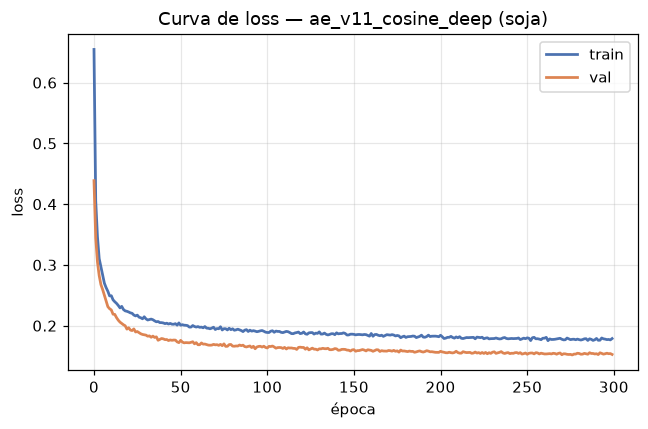

In [4]:
explib.plot_loss("ae_v11_cosine_deep", "soja"); plt.show()

El AE entrena bien (la loss converge) pero queda **por debajo del baseline y con más
varianza** — y no por falta de tuning: en la fase de exploración se probaron **24
variantes** de arquitectura y optimización (capas, latente, activaciones, dropout,
weight decay, batch norm, schedules) sin que ninguna alcanzara al IForest.
**Conclusión: los hiperparámetros del AE no eran el cuello de botella.**

## 2.2 · ¿Y si el problema es cómo se agrega el error? (score max / top-k)
Hipótesis: el MSE *promedia* sobre 54 features; si solo unas pocas reconstruyen mal, la
señal se diluye. Probamos score = **máximo error por feature** y **suma de los top-5**:

In [5]:
explib.show(explib.compare_table([
    ("ae_v11_cosine_deep","AE (MSE)"),
    ("ae_score_max","AE score=max"),
    ("ae_score_topk5","AE score=top-5")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,AE (MSE),0.474±0.047,0.712±0.030,0.317±0.041,0.487±0.052,0.216±0.028
1,AE score=max,0.388±0.026,0.624±0.018,0.282±0.035,0.432±0.032,0.191±0.024
2,AE score=top-5,0.330±0.023,0.571±0.026,0.218±0.033,0.350±0.030,0.148±0.023


**Refutado:** igual o peor. La intuición era razonable, pero un agregado *fijo*
del error no es la respuesta (guardá la idea: la versión **probabilística** de esto sí
va a funcionar, en 2.5).

## 2.3 · DAE: denoising
Entrenar reconstruyendo *limpio* desde input *corrupto* hace la representación más
robusta al ruido — otra palanca clásica de la familia:

In [6]:
explib.show(explib.compare_table([
    ("ae_v11_cosine_deep","AE"),
    ("dae_v1_base","DAE"),
    ("dae_seedens_v1","DAE seed-ensemble ×10")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,AE,0.474±0.047,0.712±0.030,0.317±0.041,0.487±0.052,0.216±0.028
1,DAE,0.383±0.072,0.649±0.060,0.367±0.115,0.408±0.057,0.155±0.050
2,DAE seed-ensemble ×10,0.413±0.003,0.693±0.002,0.427±0.010,0.462±0.005,0.176±0.008


**Tampoco:** el denoising no supera al AE y queda lejos del baseline, incluso
promediando 10 semillas. La robustez al ruido del *input* no era el problema.

## 2.4 · Híbrido de la literatura: IForest sobre el latente del AE
Hipótesis: el AE comprime, el IForest aísla en el espacio comprimido — lo mejor de los
dos mundos.

In [7]:
explib.show(explib.compare_table([
    ("iforest_v2_mf03_n200","IForest (sobre features)"),
    ("ae_iforest_v2_latent16","IForest sobre latente del AE")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest (sobre features),0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
1,IForest sobre latente del AE,0.318±0.068,0.535±0.070,0.196±0.080,0.305±0.068,0.134±0.055


**Refutado, con ganas:** peor que cada componente por separado y con la varianza
más alta de la familia. La receta asume que el latente preserva la estructura de
anomalía; en un panel heterogéneo de ~276 departamentos, el bottleneck la destruye.

## 2.5 · VAE: el hallazgo del *score probabilístico*
El VAE modela `p(x|z)` con media **y varianza** por feature. Eso habilita el score
**`recon_prob`** (An & Cho 2015): `-E[log p(x|z)]` estimado por Monte Carlo — el error
de cada feature **ponderado por la varianza que el decoder le asigna**. Es la versión
principiada de lo que `max`/`top-k` intentaba a mano. Dos experimentos lo aíslan:

**(a) Mismo VAE, distinto score** — el salto es del score, no de la arquitectura:

In [8]:
explib.show(explib.compare_table([
    ("vae_v9_negelbo_lat16_bn","VAE score=neg_elbo"),
    ("vae_v4_reconprob_lat16","VAE score=recon_prob")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE score=neg_elbo,0.474±0.039,0.691±0.022,0.322±0.031,0.446±0.036,0.219±0.020
1,VAE score=recon_prob,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018


**(b) `recon_prob` con y sin regularización pesada** — la regularización destruye la señal:

In [9]:
explib.show(explib.compare_table([
    ("vae_v4_reconprob_lat16","recon_prob limpio (v4)"),
    ("vae_v8_reconprob_reg","recon_prob + BN/dropout/β=0.5")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,recon_prob limpio (v4),0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
1,recon_prob + BN/dropout/β=0.5,0.457±0.048,0.671±0.036,0.314±0.036,0.425±0.039,0.214±0.024


La varianza per-feature del decoder ya regulariza el score; apilarle batch norm,
dropout y β bajo lo aplana. El refinamiento convergió rápido: β óptimo 1.0–1.5,
**latente 16**, hidden [64,32] (la versión profunda [128,64], `v15`, es comparable).
Config final del single:

In [10]:
explib.describe_architecture("configs/vae/vae_v4_reconprob_lat16.yaml")

Modelo: VAE
  Encoder:  54 → 64 → 32 → 16 (latente)
  Decoder:  16 → 32 → 64 → 54
  Score:    recon_prob  (recon_prob = -E[log p(x|z)], pondera por varianza per-feature)
  beta(KL): 1.0

  Optimización: lr=0.001 epochs=300 patience=30 batch=64 n_seeds=10


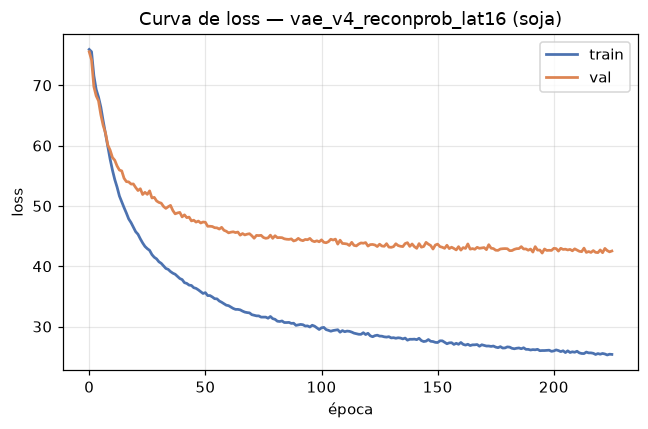

In [11]:
explib.plot_loss("vae_v4_reconprob_lat16", "soja"); plt.show()

### La familia completa, contra el baseline

In [12]:
recon = [("iforest_v2_mf03_n200","IForest (baseline)"),
         ("ae_v11_cosine_deep","AE"), ("dae_v1_base","DAE"),
         ("ae_score_max","AE score=max"), ("ae_iforest_v2_latent16","Híbrido AE+IForest"),
         ("vae_v9_negelbo_lat16_bn","VAE neg_elbo"),
         ("vae_v4_reconprob_lat16","VAE recon_prob"),
         ("vae_v15_reconprob_deep","VAE recon_prob deep")]
explib.show(explib.compare_table(recon, "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest (baseline),0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
1,AE,0.474±0.047,0.712±0.030,0.317±0.041,0.487±0.052,0.216±0.028
2,DAE,0.383±0.072,0.649±0.060,0.367±0.115,0.408±0.057,0.155±0.050
3,AE score=max,0.388±0.026,0.624±0.018,0.282±0.035,0.432±0.032,0.191±0.024
4,Híbrido AE+IForest,0.318±0.068,0.535±0.070,0.196±0.080,0.305±0.068,0.134±0.055
5,VAE neg_elbo,0.474±0.039,0.691±0.022,0.322±0.031,0.446±0.036,0.219±0.020
6,VAE recon_prob,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
7,VAE recon_prob deep,0.553±0.036,0.730±0.030,0.507±0.032,0.519±0.052,0.275±0.020


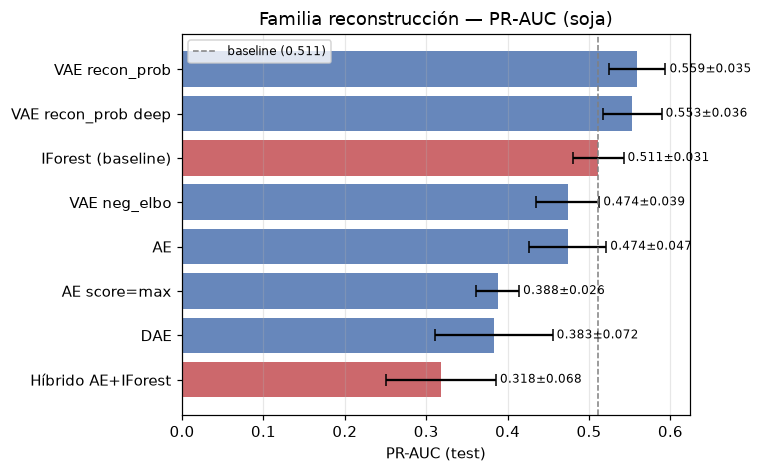

In [13]:
explib.plot_compare(recon, "soja", baseline=0.511, title="Familia reconstrucción — PR-AUC (soja)"); plt.show()

### El score, visto en las distribuciones
Score de campañas **normales** (azul) vs **anómalas** (naranja) en test. Cuanto más
separadas, mejor rankea. Se ve por qué `recon_prob` gana: corre la cola de las anómalas
más a la derecha que el MSE del AE o el híbrido.

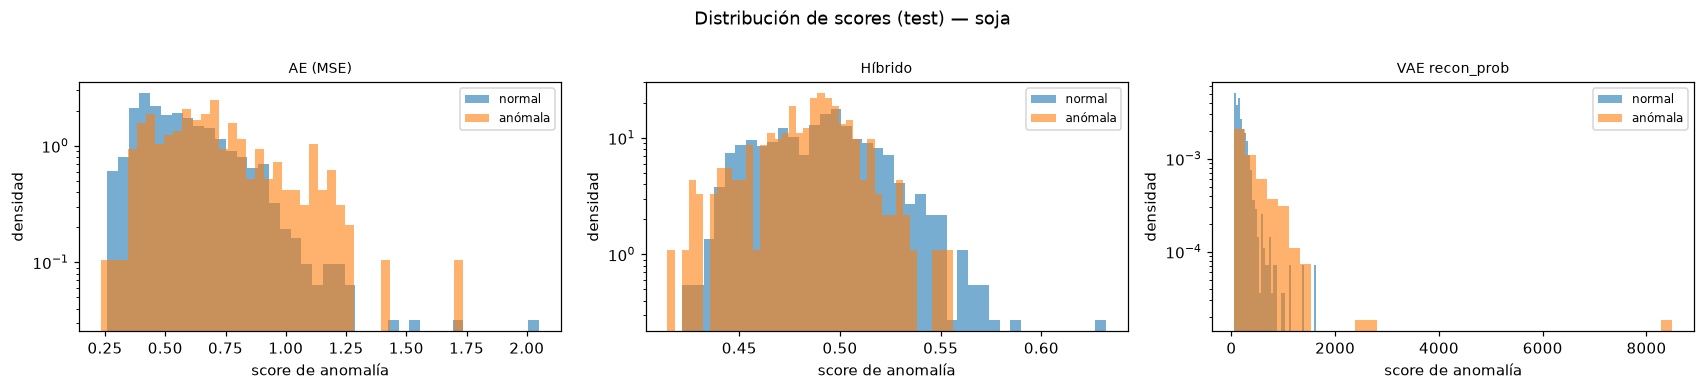

In [14]:
explib.plot_score_hist_grid([("ae_v11_cosine_deep", "AE (MSE)"),
    ("ae_iforest_v2_latent16", "Híbrido"),
    ("vae_v4_reconprob_lat16", "VAE recon_prob")], "soja", ncols=3); plt.show()

**Conclusiones del notebook:**
- AE/DAE con score MSE quedan por debajo del baseline, y no por hiperparámetros (24
  variantes), ni por el agregado del error (max/top-k refutados), ni por denoising, ni
  por combinar con IForest (híbrido refutado).
- El **VAE con `recon_prob`** es el único de la familia que supera al IForest
  (0.559 vs 0.511, soja) — y el salto es atribuible al **score** (+0.085 sobre el mismo
  VAE con `neg_elbo`), no a la arquitectura.
- La señal de `recon_prob` requiere el modelo **sin regularización pesada** (−0.10 al
  agregar BN/dropout/β bajo).

**Pero** el single tiene desvío ±0.035 entre semillas: en una corrida mala roza el
baseline. **Próximo notebook:** cómo se elimina esa varianza.